In [1]:
import numpy as np
import torch 

In [2]:
def load_coffee_data():
    rng = np.random.default_rng(2)
    X = rng.random(400)
    X = X.reshape(-1, 2)

    X[:, 0] = X[:, 0] * 110 + 150
    X[:, 1] = X[:, 1] * 4 + 11.5

    Y = np.zeros(len(X))

    for i, (t, d) in enumerate(X):
        y = -3 / (260 - 175) * t + 21  
        if 175 < t < 260 and 12 < d < 15 and d <= y:
            Y[i] = 1   

    return X, Y.reshape(-1, 1)

In [3]:
X_np, Y_np = load_coffee_data()
print(X_np.shape)
print(Y_np.shape)
print(Y_np.sum())

from sklearn.model_selection import train_test_split

X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(X_np, Y_np, test_size=0.2, random_state=2)

(200, 2)
(200, 1)
54.0


In [4]:
X_train = torch.tensor(X_train_np, dtype=torch.float32)
X_test = torch.tensor(X_test_np, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.float32)
y_test = torch.tensor(y_test_np, dtype=torch.float32)

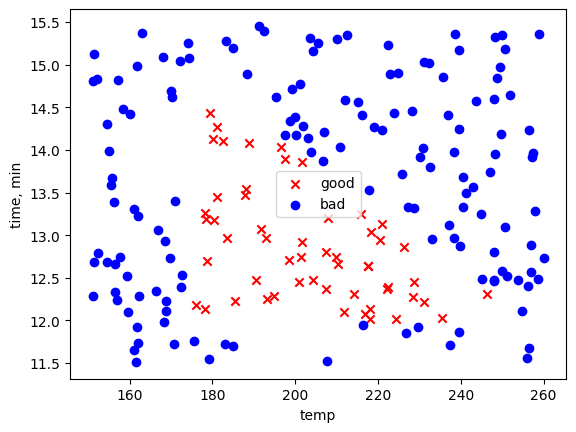

In [5]:
good = (Y_np == 1).flatten()
bad = (Y_np == 0).flatten()

X_np[good]
X_np[bad]

import matplotlib.pyplot as plt

plt.scatter(X_np[good][:, 0], X_np[good][:, 1], c="red", marker="x", label = "good")
plt.scatter(X_np[bad][:, 0], X_np[bad][:, 1], c="blue", marker="o", label="bad")
plt.xlabel("temp")
plt.ylabel("time, min")
plt.legend()
#plt.show()

In [8]:
mean = X_train.mean(dim=0)
std = X_train.std(dim = 0)
X_train_norm = (X_train - mean) / std
X_test_norm = (X_test - mean) / std

print(X_train_norm.mean(dim=0))
print(X_train_norm.std(dim=0))
print(X_test_norm.mean(dim=0))

tensor([-2.8610e-07,  8.3447e-07])
tensor([1.0000, 1.0000])
tensor([-0.0379, -0.0894])


In [21]:
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(2, 3),
    nn.Sigmoid(),
    nn.Linear(3, 1),
    nn.Sigmoid()
)

In [22]:
print(model)
print(sum(p.numel() for p in model.parameters())) 

Sequential(
  (0): Linear(in_features=2, out_features=3, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=3, out_features=1, bias=True)
  (3): Sigmoid()
)
13


epoch 0: loss = 0.7348
epoch 100: loss = 0.5289
epoch 200: loss = 0.4962
epoch 300: loss = 0.4319
epoch 400: loss = 0.3683
epoch 500: loss = 0.3122
epoch 600: loss = 0.2615
epoch 700: loss = 0.2294
epoch 800: loss = 0.2066
epoch 900: loss = 0.1901
epoch 1000: loss = 0.1763
epoch 1100: loss = 0.1631
epoch 1200: loss = 0.1505
epoch 1300: loss = 0.1400
epoch 1400: loss = 0.1316
epoch 1500: loss = 0.1247
epoch 1600: loss = 0.1187
epoch 1700: loss = 0.1114
epoch 1800: loss = 0.0878
epoch 1900: loss = 0.0751
epoch 2000: loss = 0.0659
epoch 2100: loss = 0.0584
epoch 2200: loss = 0.0521
epoch 2300: loss = 0.0468
epoch 2400: loss = 0.0423
epoch 2500: loss = 0.0384
epoch 2600: loss = 0.0351
epoch 2700: loss = 0.0321
epoch 2800: loss = 0.0295
epoch 2900: loss = 0.0272
epoch 3000: loss = 0.0251
epoch 3100: loss = 0.0233
epoch 3200: loss = 0.0216
epoch 3300: loss = 0.0201
epoch 3400: loss = 0.0187
epoch 3500: loss = 0.0174
epoch 3600: loss = 0.0162
epoch 3700: loss = 0.0151
epoch 3800: loss = 0.014

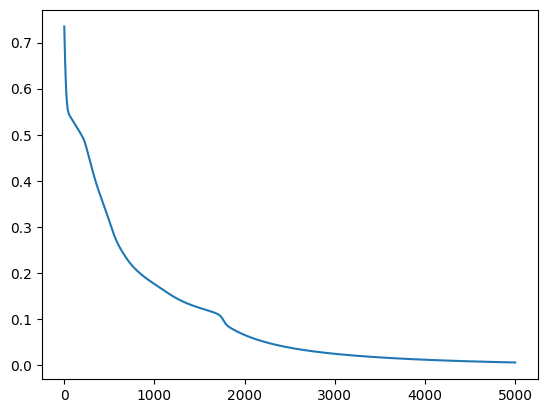

In [23]:
loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)
losses = []

for epoch in range(5000):
    pred = model(X_train_norm)
    loss = loss_fn(pred, y_train)
    losses.append(loss.item())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"epoch {epoch}: loss = {loss.item():.4f}")

plt.plot(losses)

In [20]:
with torch.no_grad():
    test_pred = model(X_test_norm)

predicted_class = (test_pred > 0.5).float()
accuracy = (predicted_class == y_test).float().mean()
print(accuracy)

tensor(1.)


In [26]:
t = np.linspace(150, 260, 200)
d = np.linspace(11.5, 15.5, 200)
TT, DD = np.meshgrid(t, d)

grid = np.c_[TT.ravel(), DD.ravel()]
grid_t = torch.tensor(grid, dtype=torch.float32)
grid_n = (grid_t - mean) / std
with torch.no_grad():
    probs = model(grid_n)

probs = model(grid_n).reshape(TT.shape)

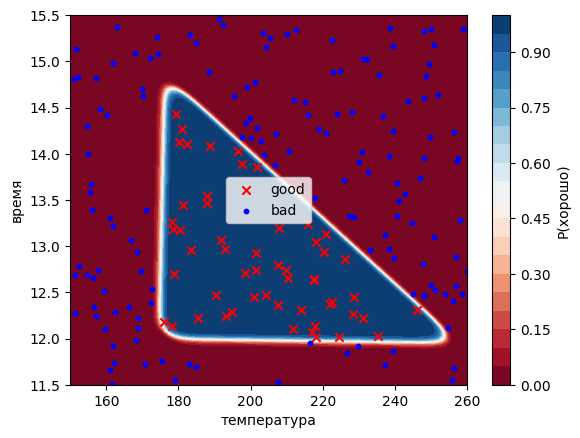

In [28]:
plt.contourf(TT, DD, probs.detach().numpy(), levels=20, cmap="RdBu")
plt.colorbar(label="P(хорошо)")
plt.scatter(X_np[good][:, 0], X_np[good][:, 1], c="red",  marker="x", label="good")
plt.scatter(X_np[bad][:, 0],  X_np[bad][:, 1],  c="blue", marker="o", s=10, label="bad")
plt.xlabel("температура")
plt.ylabel("время")
plt.legend()
plt.show()